# 用于手写数字识别的神经网络（二分类）

在本练习中，您将使用神经网络识别手写数字 0 和 1。


# 大纲
- [1——软件包](#1)
- [2——神经网络](#2)
  - [2.1 问题陈述](#2.1)
  - [2.2 数据集](#2.2)
  - [2.3 模型表示](#2.3)
  - [2.4 TensorFlow 模型实现](#2.4)
    - [练习 1](#ex01)
  - [2.5 NumPy 模型实现（NumPy 中的前向传播）](#2.5)
    - [练习 2](#ex02)
  - [2.6 向量化 NumPy 模型实现（可选）](#2.6)
    - [练习 3](#ex03)
  - [2.7 恭喜！](#2.7)
  - [2.8 NumPy 广播教程（可选）](#2.8)

<a name="1"></a>
## 1 - 软件包

首先运行下面的单元格，导入本作业期间需要的所有软件包。
- [numpy](https://numpy.org/) 是使用 Python 进行科学计算的基础软件包。
- [matplotlib](http://matplotlib.org) 是一个常用的 Python 绘图库。
- [tensorflow](https://www.tensorflow.org/) 是一个常用的机器学习平台。

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from autils import *
%matplotlib inline

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

**TensorFlow 和 Keras**  
TensorFlow 是 Google 开发的机器学习软件包。2019 年，Google 将 Keras 集成到 TensorFlow 中，并发布了 TensorFlow 2.0。Keras 是由 François Chollet 独立开发的框架，它为 TensorFlow 提供了一个简单的、以层为中心的接口。本课程将使用 Keras 接口。

<a name="2"></a>
## 2 - 神经网络

在课程 1 中，你实现了逻辑回归，并使用多项式回归将其扩展到处理非线性边界。对于图像识别等更复杂的场景，神经网络更为合适。

<a name="2.1"></a>
### 2.1 问题陈述

在本练习中，你将使用神经网络识别两个手写数字：0 和 1。这是一项二分类任务。如今，手写数字自动识别已得到广泛应用——从识别信封上的邮政编码，到识别银行支票上书写的金额。在后续作业中，你会将该网络扩展为识别全部 10 个数字（0～9）。

本练习将向你展示如何使用所学方法完成这项分类任务。

<a name="2.2"></a>
### 2.2 数据集

首先，加载本任务所需的数据集。
- 下面所示的 `load_data()` 函数将数据加载到变量 `X` 和 `y` 中


- 数据集包含 1000 个手写数字 $^1$ 的训练样本，此处仅限于数字 0 和 1。

    - 每个训练样本是一幅 20 像素×20 像素的数字灰度图像。
        - 每个像素由一个浮点数表示，该数指示该位置的灰度强度。
        - 20×20 的像素网格被“展开”为一个 400 维向量。
        - 每个训练样本成为数据矩阵 `X` 中的一行。
        - 由此得到一个 1000×400 的矩阵 `X`，其中每一行都是一幅手写数字图像的训练样本。

$$X = 
\left(\begin{array}{cc} 
--- (x^{(1)}) --- \\
--- (x^{(2)}) --- \\
\vdots \\ 
--- (x^{(m)}) --- 
\end{array}\right)$$ 

- 训练集的第二部分是一个 1000×1 维向量 `y`，其中包含训练集的标签
    - 如果图像中的数字是 `0`，则为 `y = 0`；如果图像中的数字是 `1`，则为 `y = 1`。

$^1$<sub> 这是 MNIST 手写数字数据集的一个子集（http://yann.lecun.com/exdb/mnist/）</sub>

In [3]:
# load dataset
X, y = load_data()

<a name="toc_89367_2.2.1"></a>
#### 2.2.1 查看变量
让我们进一步熟悉你的数据集。
- 一个很好的起点是打印每个变量，看看其中包含什么。

下面的代码打印变量 `X` 和 `y` 中的元素。

In [4]:
print ('The first element of X is: ', X[0])

The first element of X is:  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+

In [5]:
print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  1


<a name="toc_89367_2.2.2"></a>
#### 2.2.2 检查变量的维度

另一种熟悉数据的方法是查看其维度。请打印 `X` 和 `y` 的形状，看看数据集中有多少个训练样本。

In [6]:
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))

The shape of X is: (1000, 400)
The shape of y is: (1000, 1)


<a name="toc_89367_2.2.3"></a>
#### 2.2.3 数据可视化

首先，你将对训练集的一个子集进行可视化。
- 在下面的单元格中，代码会从 `X` 中随机选择 64 行，将每一行还原为一幅 20 像素×20 像素的灰度图像，并将这些图像一起显示。
- 每幅图像的标签显示在图像上方

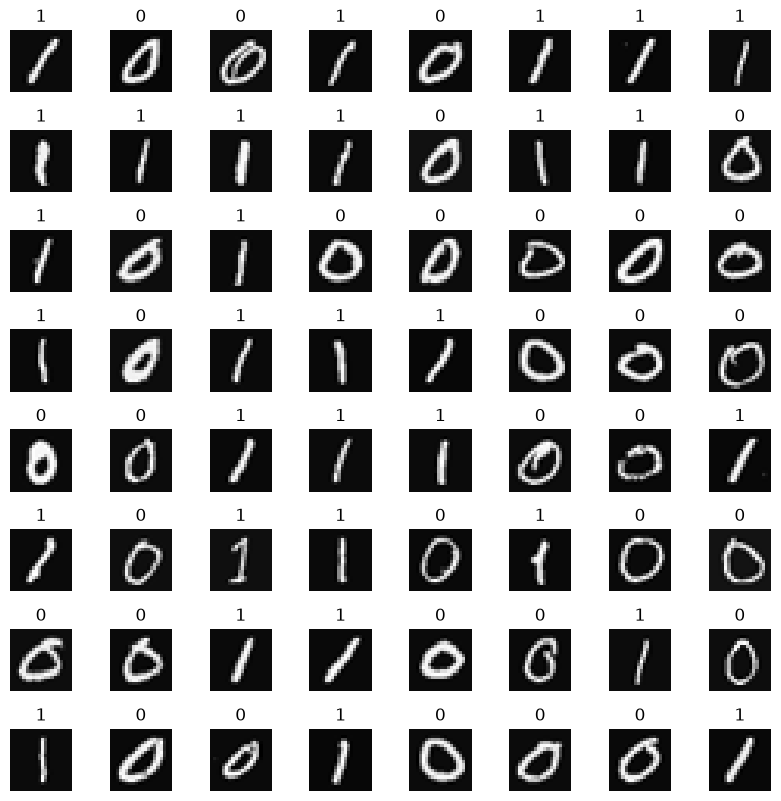

In [7]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1)

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Display the label above the image
    ax.set_title(y[random_index,0])
    ax.set_axis_off()

<a name="2.3"></a>
### 2.3 模型表示

本作业中使用的神经网络如下图所示。
- 它包含三个使用 sigmoid 激活的全连接层。
    - 回想一下，我们的输入是数字图像的像素值。
    - 由于图像尺寸为 $20\times20$，因此有 $400$ 个输入

<img src="images/C2_W1_Assign1.PNG" width="500" height="400">

- 这些参数的维度适用于如下神经网络：第 1 层有 $25$ 个单元，第 2 层有 $15$ 个单元，第 3 层有 $1$ 个输出单元。

    - 回顾一下，这些参数的维度按以下方式确定：
        - 如果网络某一层有 $s_{in}$ 个单元，下一层有 $s_{out}$ 个单元，那么
            - $W$ 的维度将为 $s_{in} \times s_{out}$。
            - $b$ 将是一个包含 $s_{out}$ 个元素的向量。
  
    - 因此，`W` 和 `b` 的形状为：
        - 第 1 层：`W1` 的形状是 (400, 25)，`b1` 的形状是 (25,)
        - 第 2 层：`W2` 的形状是 (25, 15)，`b2` 的形状是 (15,)
        - 第 3 层：`W3` 的形状是 (15, 1)，`b3` 的形状是 (1,)
>**注意：** 偏置向量 `b` 可以表示为一维数组 (n,) 或二维数组 (n,1)。TensorFlow 使用一维表示，本实验也将沿用这一约定。
               

<a name="2.4"></a>
### 2.4 TensorFlow 模型实现

TensorFlow 模型是逐层构建的。系统会自动为你计算某层的输入维度（上面的 $s_{in}$）。你需要指定该层的*输出维度*，这将决定下一层的输入维度。第一层的输入维度来自下面 `model.fit` 语句中指定的输入数据大小。
>**注意：** 也可以添加一个输入层，指定第一层的输入维度。例如：
`tf.keras.Input(shape=(400,)),    #specify input shape`  
这里将包含该输入层，以说明模型大小的确定方式。

<a name="ex01"></a>
### 练习 1

下面，使用 Keras 的[顺序模型](https://keras.io/guides/sequential_model/)和带 sigmoid 激活函数的[密集层](https://keras.io/api/layers/core_layers/dense/)，构建上述网络。

In [18]:
# UNQ_C1
# GRADED CELL: Sequential model

model = Sequential(
    [               
        tf.keras.Input(shape=(400,)),    #specify input size
        ### START CODE HERE ### 
        Dense(25, activation='sigmoid'),
        Dense(15, activation='sigmoid'),
        Dense(1, activation='sigmoid'),
        ### END CODE HERE ### 
    ], name = "my_model" 
)                            


In [19]:
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 25)                  │          10,025 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 15)                  │             390 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,431 (40.75 KB)

 Trainable params: 10,431 (40.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
import keras

In [21]:
print(model.inputs)
print(model.input_shape)
print(tf.__version__)
print(keras.__version__)

[<KerasTensor shape=(None, 400), dtype=float32, sparse=False, ragged=False, name=keras_tensor_4>]
(None, 400)
2.21.0
3.15.1


<details>
  <summary><font size="3" color="darkgreen"><b>预期输出（点击展开）</b></font></summary>
`model.summary()` 函数会显示有用的模型摘要。由于我们指定了输入层大小，权重和偏置数组的形状已经确定，因此可以显示每层的参数总数。请注意，层名称是自动生成的，可能会有所不同。
    
    
```
Model: "my_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
dense (Dense)                (None, 25)                10025     
_________________________________________________________________
dense_1 (Dense)              (None, 15)                390       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 16        
=================================================================
Total params: 10,431
Trainable params: 10,431
Non-trainable params: 0
_________________________________________________________________
```

<details>
  <summary><font size="3" color="darkgreen"><b>单击查看提示</b></font></summary>
如课程中所述：
    
```python
model = Sequential(                      
    [                                   
        tf.keras.Input(shape=(400,)),    # specify input size (optional)
        Dense(25, activation='sigmoid'), 
        Dense(15, activation='sigmoid'), 
        Dense(1,  activation='sigmoid')  
    ], name = "my_model"                                    
)                                       
``` 

In [22]:
# UNIT TESTS
from public_tests import * 

test_c1(model)

All tests passed!


摘要中显示的参数数量，对应于下面所示权重数组和偏置数组中的元素数量。

In [23]:
L1_num_params = 400 * 25 + 25  # W1 parameters  + b1 parameters
L2_num_params = 25 * 15 + 15   # W2 parameters  + b2 parameters
L3_num_params = 15 * 1 + 1     # W3 parameters  + b3 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params, ",  L3 params = ", L3_num_params )

L1 params =  10025 , L2 params =  390 ,  L3 params =  16


让我们进一步检查权重，以验证 TensorFlow 生成的维度是否与上面的计算相同。

In [24]:
[layer1, layer2, layer3] = model.layers

In [25]:
#### Examine Weights shapes
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 1), b3 shape = (1,)


**预期输出**
```
W1 shape = (400, 25), b1 shape = (25,)  
W2 shape = (25, 15), b2 shape = (15,)  
W3 shape = (15, 1), b3 shape = (1,)
```

`xx.get_weights` 返回一个 NumPy 数组。也可以直接以张量形式访问权重。请注意最后一层中张量的形状。

In [26]:
print(model.layers[2].weights)

[<Variable path=my_model/dense_5/kernel, shape=(15, 1), dtype=float32, value=[[-3.6055422e-01]
 [ 5.2827972e-01]
 [-1.4129841e-01]
 [-3.4827918e-01]
 [ 3.4923041e-01]
 [ 2.0483321e-01]
 [-5.5803764e-01]
 [ 5.2590662e-01]
 [ 1.3990307e-01]
 [-7.6661050e-02]
 [ 5.6899947e-01]
 [ 2.6087135e-01]
 [-3.4439564e-04]
 [ 1.8304640e-01]
 [ 2.4439275e-01]]>, <Variable path=my_model/dense_5/bias, shape=(1,), dtype=float32, value=[0.]>]


以下代码将定义一个损失函数，并运行梯度下降，使模型权重拟合训练数据。下一周将对此进行更详细的说明。

In [27]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
)

model.fit(
    X,y,
    epochs=20
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6623   
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5169 
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3769 
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2651 
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1923 
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1461 
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1164 
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0958 
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0808 
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0694 
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0605 
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0535 
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0478 
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0431 
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0393 
Ep

要在一个样本上运行模型并进行预测，请使用 [Keras `predict`](https://www.tensorflow.org/api_docs/python/tf/keras/Model)。`predict` 的输入是一个数组，因此需要将单个样本重塑为二维形式。

In [18]:
prediction = model.predict(X[0].reshape(1,400))  # a zero
print(f" predicting a zero: {prediction}")
prediction = model.predict(X[500].reshape(1,400))  # a one
print(f" predicting a one:  {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
 predicting a zero: [[0.00104809]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
 predicting a one:  [[0.9954982]]


模型的输出被解释为概率。在上面的第一个示例中，输入为 0，模型预测该输入为 1 的概率接近 0。
在第二个示例中，输入为 1，模型预测该输入为 1 的概率接近 1。
与逻辑回归一样，需要将概率与阈值进行比较，才能得到最终预测。

In [19]:
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print(f"prediction after threshold: {yhat}")

prediction after threshold: 1


让我们比较随机抽取的 64 个数字的预测值与标签。运行需要一些时间。

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

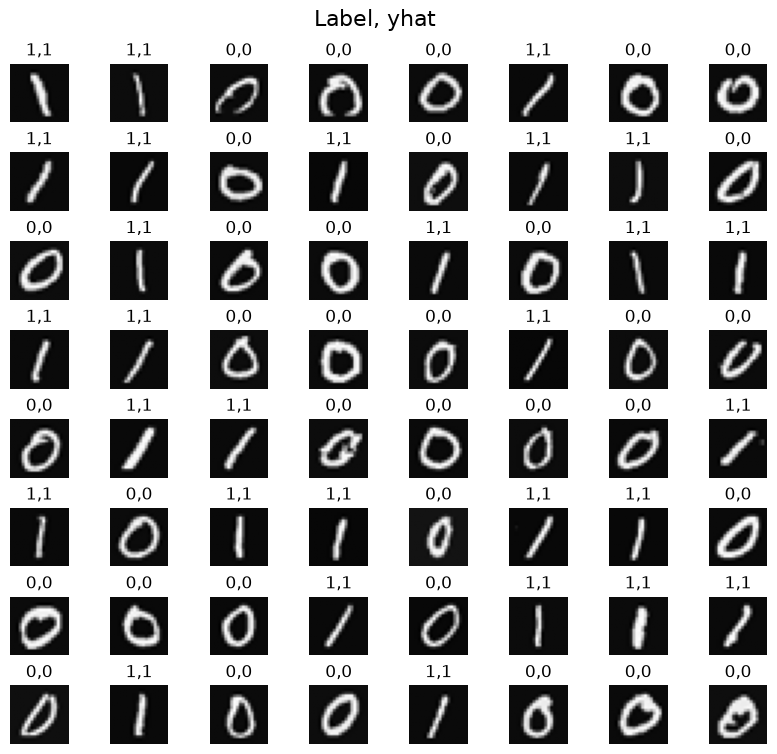

In [20]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Predict using the Neural Network
    prediction = model.predict(X[random_index].reshape(1,400))
    if prediction >= 0.5:
        yhat = 1
    else:
        yhat = 0
    
    # Display the label above the image
    ax.set_title(f"{y[random_index,0]},{yhat}")
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=16)
plt.show()

<a name="2.5"></a>
### 2.5 NumPy 模型实现（使用 NumPy 进行前向传播）
如课程中所述，可以使用 NumPy 构建自己的全连接层，进而用它构建多层神经网络。

<img src="images/C2_W1_dense2.PNG" width="600" height="450">

<a name="ex02"></a>
### 练习 2

在下面构建一个全连接层子程序。课程示例使用 for 循环访问该层中的每个单元（`j`），计算该单元权重（`W[:,j]`）与输入的点积，再加上该单元的偏置（`b[j]`），形成 `z`。然后对结果应用激活函数 `g(z)`。本节不会使用可选课程中介绍的部分矩阵运算，后续章节会继续探索这些内容。

In [25]:
# UNQ_C2
# GRADED FUNCTION: my_dense

def my_dense(a_in, W, b, g):
    """
    Computes dense layer
    Args:
      a_in (ndarray (n, )) : Data, 1 example 
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j, )) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      a_out (ndarray (j,))  : j units
    """
    units = W.shape[1]
    a_out = np.zeros(units)
### START CODE HERE ### 
    for j in range(units):
        w = W[:,j]
        z = np.dot(w, a_in) + b[j]
        a_out[j] = g(z)
### END CODE HERE ### 
    return(a_out)


In [26]:
# Quick Check
x_tst = 0.1*np.arange(1,3,1).reshape(2,)  # (1 examples, 2 features)
W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
b_tst = 0.1*np.arange(1,4,1).reshape(3,)  # (3 features)
A_tst = my_dense(x_tst, W_tst, b_tst, sigmoid)
print(A_tst)

[0.54735762 0.57932425 0.61063923]


**预期输出**
```
[0.54735762 0.57932425 0.61063923]
```

<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
如课程中所述：
    
```python
def my_dense(a_in, W, b, g):
    """
    Computes dense layer
    Args:
      a_in (ndarray (n, )) : Data, 1 example 
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j, )) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      a_out (ndarray (j,))  : j units
    """
    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):             
        w =                            # Select weights for unit j. These are in column j of W
        z =                            # dot product of w and a_in + b
        a_out[j] =                     # apply activation to z
    return(a_out)
```
   
    
<details>
  <summary><font size="3" color="darkgreen"><b>点击查看更多提示</b></font></summary>

    
```python
def my_dense(a_in, W, b, g):
    """
    Computes dense layer
    Args:
      a_in (ndarray (n, )) : Data, 1 example 
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j, )) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      a_out (ndarray (j,))  : j units
    """
    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):             
        w = W[:,j]                     
        z = np.dot(w, a_in) + b[j]     
        a_out[j] = g(z)                
    return(a_out)
```

In [27]:
# UNIT TESTS
test_c2(my_dense)

All tests passed!


下面的单元格使用上述 `my_dense` 子例程构建一个三层神经网络。

In [29]:
def my_sequential(x, W1, b1, W2, b2, W3, b3):
    a1 = my_dense(x,  W1, b1, sigmoid)
    a2 = my_dense(a1, W2, b2, sigmoid)
    a3 = my_dense(a2, W3, b3, sigmoid)
    return(a3)

我们可以从 TensorFlow 复制训练好的权重和偏置。

In [30]:
W1_tmp,b1_tmp = layer1.get_weights()
W2_tmp,b2_tmp = layer2.get_weights()
W3_tmp,b3_tmp = layer3.get_weights()

In [31]:
# make predictions
prediction = my_sequential(X[0], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print( "yhat = ", yhat, " label= ", y[0,0])
prediction = my_sequential(X[500], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print( "yhat = ", yhat, " label= ", y[500,0])

yhat =  0  label=  0
yhat =  1  label=  1


运行下面的单元格，查看 NumPy 模型和 TensorFlow 模型的预测结果。运行需要一点时间。

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


C:\Windows\Temp\ipykernel_28548\1208669724.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  my_yhat = int(my_prediction >= 0.5)
C:\Windows\Temp\ipykernel_28548\1208669724.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tf_yhat = int(tf_prediction >= 0.5)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━

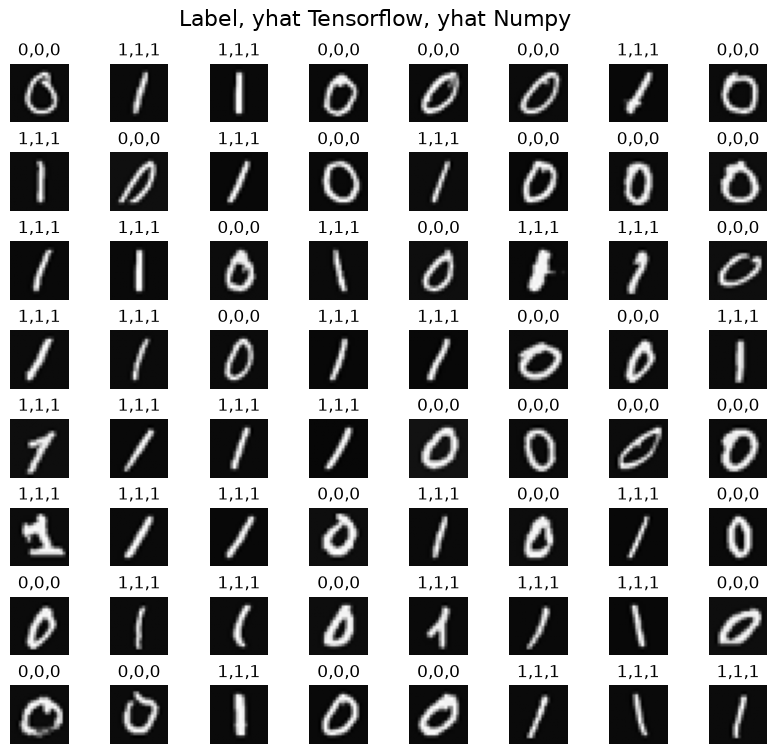

In [32]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    # Predict using the Neural Network implemented in Numpy
    my_prediction = my_sequential(X[random_index], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
    my_yhat = int(my_prediction >= 0.5)

    # Predict using the Neural Network implemented in Tensorflow
    tf_prediction = model.predict(X[random_index].reshape(1,400))
    tf_yhat = int(tf_prediction >= 0.5)
    
    # Display the label above the image
    ax.set_title(f"{y[random_index,0]},{tf_yhat},{my_yhat}")
    ax.set_axis_off() 
fig.suptitle("Label, yhat Tensorflow, yhat Numpy", fontsize=16)
plt.show()

<a name="2.6"></a>
### 2.6 向量化 NumPy 模型实现（可选）
可选课程介绍了可用于加速计算的向量和矩阵运算。
下面描述了一种层运算：针对给定输入样本，计算该层中所有单元的输出：

<img src="images/C2_W1_VectorMatrix.PNG" width="600" height="450">

可以使用上面的样本 `X` 和参数 `W1`、`b1` 演示这一点。我们使用 `np.matmul` 执行矩阵乘法。请注意，x 和 W 的维度必须兼容，如上图所示。

In [33]:
x = X[0].reshape(-1,1)         # column vector (400,1)
z1 = np.matmul(x.T,W1) + b1    # (1,400)(400,25) = (1,25)
a1 = sigmoid(z1)
print(a1.shape)

(1, 25)


还可以再进一步，通过一次矩阵-矩阵运算计算所有样本的全部单元。

<img src="images/C2_W1_MatrixMatrix.PNG" width="600" height="450">
完整运算为 $\mathbf{Z}=\mathbf{XW}+\mathbf{b}$。这将利用 NumPy 广播把 $\mathbf{b}$ 扩展为 $m$ 行。如果你不熟悉这一点，notebook 末尾提供了一个简短教程。

<a name="ex03"></a>
### 练习 3

下面，构建一个新的 `my_dense_v` 子例程，对样本矩阵执行层计算。该例程将使用 `np.matmul()`。

In [34]:
# UNQ_C3
# GRADED FUNCTION: my_dense_v

def my_dense_v(A_in, W, b, g):
    """
    Computes dense layer
    Args:
      A_in (ndarray (m,n)) : Data, m examples, n features each
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j,1)) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      A_out (ndarray (m,j)) : m examples, j units
    """
### START CODE HERE ### 
    Z = np.matmul(A_in, W) + b
    A_out = g(Z)
    return(A_out)
    
### END CODE HERE ### 
    return(A_out)

In [35]:
X_tst = 0.1*np.arange(1,9,1).reshape(4,2) # (4 examples, 2 features)
W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
b_tst = 0.1*np.arange(1,4,1).reshape(1,3) # (3 features, 1)
A_tst = my_dense_v(X_tst, W_tst, b_tst, sigmoid)
print(A_tst)

tf.Tensor(
[[0.54735762 0.57932425 0.61063923]
 [0.57199613 0.61301418 0.65248946]
 [0.5962827  0.64565631 0.6921095 ]
 [0.62010643 0.67699586 0.72908792]], shape=(4, 3), dtype=float64)


**预期输出**

```
[[0.54735762 0.57932425 0.61063923]
 [0.57199613 0.61301418 0.65248946]
 [0.5962827  0.64565631 0.6921095 ]
 [0.62010643 0.67699586 0.72908792]]
 ```

<details>
  <summary><font size="3" color="darkgreen"><b>单击查看提示</b></font></summary>
    采用矩阵形式时，可以用一两行代码编写。
    
       Z = np.matmul of A_in and W plus b    
       A_out is g(Z)  
<details>
  <summary><font size="3" color="darkgreen"><b>单击查看代码</b></font></summary>

```python
def my_dense_v(A_in, W, b, g):
    """
    Computes dense layer
    Args:
      A_in (ndarray (m,n)) : Data, m examples, n features each
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j,1)) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      A_out (ndarray (m,j)) : m examples, j units
    """
    Z = np.matmul(A_in,W) + b    
    A_out = g(Z)                 
    return(A_out)
```

In [36]:
# UNIT TESTS
test_c3(my_dense_v)

All tests passed!


下面的单元格使用上述 `my_dense_v` 子例程构建一个三层神经网络。

In [37]:
def my_sequential_v(X, W1, b1, W2, b2, W3, b3):
    A1 = my_dense_v(X,  W1, b1, sigmoid)
    A2 = my_dense_v(A1, W2, b2, sigmoid)
    A3 = my_dense_v(A2, W3, b3, sigmoid)
    return(A3)

我们可以再次从 TensorFlow 复制训练后的权重和偏置。

In [38]:
W1_tmp,b1_tmp = layer1.get_weights()
W2_tmp,b2_tmp = layer2.get_weights()
W3_tmp,b3_tmp = layer3.get_weights()

让我们使用新模型进行预测。这将*一次性对所有样本*进行预测。请注意输出的形状。

In [39]:
Prediction = my_sequential_v(X, W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
Prediction.shape

TensorShape([1000, 1])

与之前一样，我们将应用 0.5 的阈值，但这次同时应用于所有预测。

In [40]:
Yhat = (Prediction >= 0.5).numpy().astype(int)
print("predict a zero: ",Yhat[0], "predict a one: ", Yhat[500])

predict a zero:  [0] predict a one:  [1]


运行下面的单元格以查看预测结果。它将使用我们刚刚在上面计算的预测，运行需要一点时间。

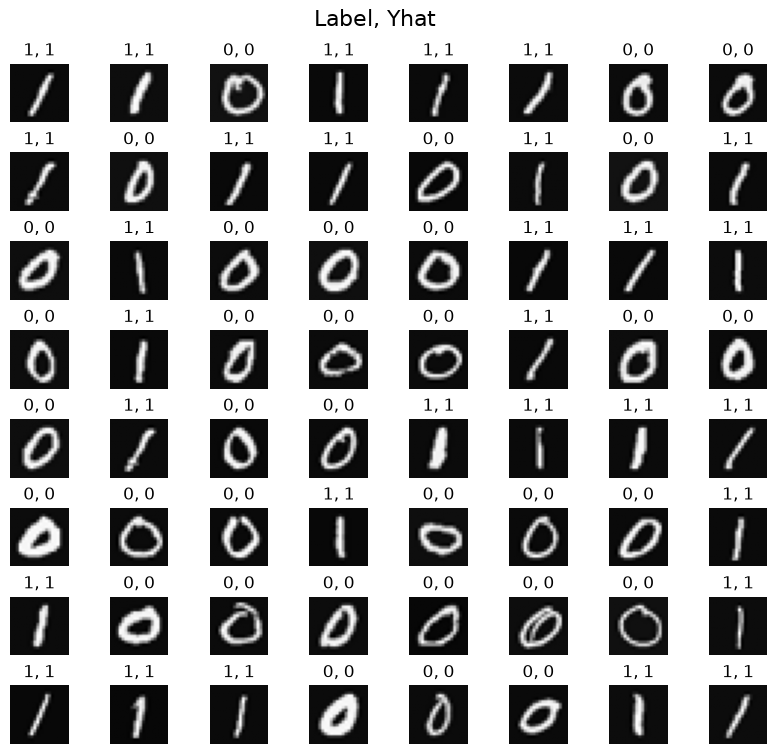

In [42]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i, ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20, 20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
   
    # Display the label above the image
    ax.set_title(f"{y[random_index,0]}, {Yhat[random_index, 0]}")
    ax.set_axis_off() 
fig.suptitle("Label, Yhat", fontsize=16)
plt.show()

您可以看看其中一张被错误分类的图像是什么样子。

In [43]:
fig = plt.figure(figsize=(1, 1))
errors = np.where(y != Yhat)
random_index = errors[0][0]
X_random_reshaped = X[random_index].reshape((20, 20)).T
plt.imshow(X_random_reshaped, cmap='gray')
plt.title(f"{y[random_index,0]}, {Yhat[random_index, 0]}")
plt.axis('off')
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

<Figure size 100x100 with 0 Axes>

<a name="2.7"></a>
### 2.7 恭喜！
您已成功构建并使用了一个神经网络。

<a name="2.8"></a>
### 2.8 NumPy 广播教程（可选）

在上一个示例中，$\mathbf{Z}=\mathbf{XW} + \mathbf{b}$ 利用 NumPy 广播来扩展向量 $\mathbf{b}$。如果你不熟悉 NumPy 广播，这里提供了一个简短教程。

$\mathbf{XW}$ 是一个维度为 $(m,j_1)(j_1,j_2)$ 的矩阵-矩阵运算，运算结果是维度为 $(m,j_2)$ 的矩阵。然后，我们再加上一个维度为 $(j_2,)$ 的向量 $\mathbf{b}$。为了使这个逐元素运算有意义，必须将 $\mathbf{b}$ 扩展为一个 $(m,j_2)$ 矩阵。NumPy 广播会自动为你完成这种扩展。

广播适用于逐元素运算。  
其基本操作是复制元素以“拉伸”较小的维度，使其与较大的维度匹配。

更[具体地说](https://NumPy.org/doc/stable/user/basics.broadcasting.html)：
对两个数组执行运算时，NumPy 会逐元素比较它们的形状。它从尾部（即最右侧）维度开始，逐步向左比较。两个维度在以下情况下兼容：
- 两者相等；或者
- 其中一个为 1

如果不满足这些条件，将抛出 ValueError: operands could not be broadcast together 异常，表示数组形状不兼容。结果数组沿输入各坐标轴的大小，取该轴上不为 1 的大小。

下面是一些示例：

<figure>
    <center> <img src="./images/C2_W1_Assign1_BroadcastIndexes.PNG"  alt='missing' width="400"  ><center/>
    <figcaption>计算广播结果的形状</figcaption>
<figure/>

下图描述了维度扩展。请注意下方的红色文字：

<figure>
    <center> <img src="./images/C2_W1_Assign1_Broadcasting.gif"  alt='missing' width="600"  ><center/>
    <figcaption>广播在概念上会扩展参数，使其匹配以执行逐元素运算</figcaption>
<figure/>

上图展示了 NumPy 在最终运算前扩展参数以使其匹配的过程。请注意，这只是概念性说明；NumPy 运算的实际机制会选择最高效的实现。

对于下面的每个示例，请在运行之前尝试猜测结果的大小。

In [44]:
a = np.array([1,2,3]).reshape(-1,1)  #(3,1)
b = 5
print(f"(a + b).shape: {(a + b).shape}, \na + b = \n{a + b}")

(a + b).shape: (3, 1), 
a + b = 
[[6]
 [7]
 [8]]


请注意，这适用于所有逐元素运算：

In [45]:
a = np.array([1,2,3]).reshape(-1,1)  #(3,1)
b = 5
print(f"(a * b).shape: {(a * b).shape}, \na * b = \n{a * b}")

(a * b).shape: (3, 1), 
a * b = 
[[ 5]
 [10]
 [15]]


<figure>
    <img src="./images/C2_W1_Assign1_VectorAdd.PNG"  alt='missing' width="740" >
    <center><figcaption><b>行列逐元素运算</b></figcaption></center>
<figure/>

In [46]:
a = np.array([1,2,3,4]).reshape(-1,1)
b = np.array([1,2,3]).reshape(1,-1)
print(a)
print(b)
print(f"(a + b).shape: {(a + b).shape}, \na + b = \n{a + b}")

[[1]
 [2]
 [3]
 [4]]
[[1 2 3]]
(a + b).shape: (4, 3), 
a + b = 
[[2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 7]]


这就是你在上面构建的密集层中的情形：将一个一维向量 $b$ 与一个 (m,j) 矩阵相加。
<figure>
    <img src="./images/C2_W1_Assign1_BroadcastMatrix.PNG"  alt='missing' width="740" >
    <center><figcaption><b>矩阵 + 一维向量</b></figcaption></center>
<figure/>